In [53]:
import kagglehub
import pandas as pd
import os


# Download latest version
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

data_dir = os.path.join(path, "data")
rows = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            rows.append([img_path, label])

df = pd.DataFrame(rows, columns=["image_path", "label"])
df.to_csv("satellite_dataset.csv", index=False)

print(df.head())

Path to dataset files: /Users/talasu/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1
                                          image_path   label
0  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
1  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
2  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
3  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy
4  /Users/talasu/.cache/kagglehub/datasets/mahmou...  cloudy


Dataset Exploration

In [54]:
images = df.groupby("label")["image_path"].apply(list).to_dict()
image_count = df['label'].value_counts().to_dict()
print(image_count)
total_images = len(df)
print(f"Total images: {total_images}")

{'cloudy': 1500, 'water': 1500, 'green_area': 1500, 'desert': 1131}
Total images: 5631


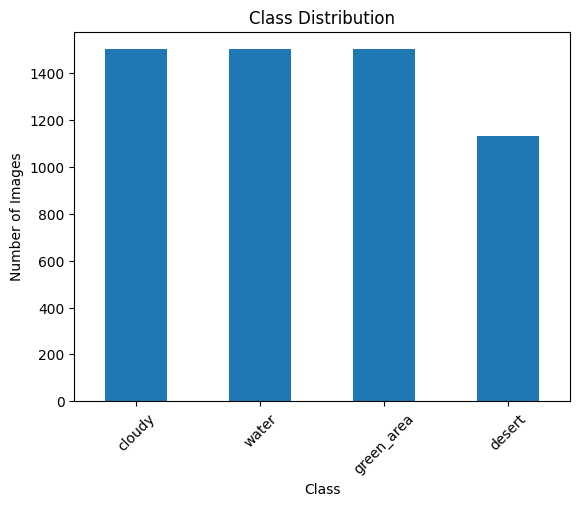

In [55]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

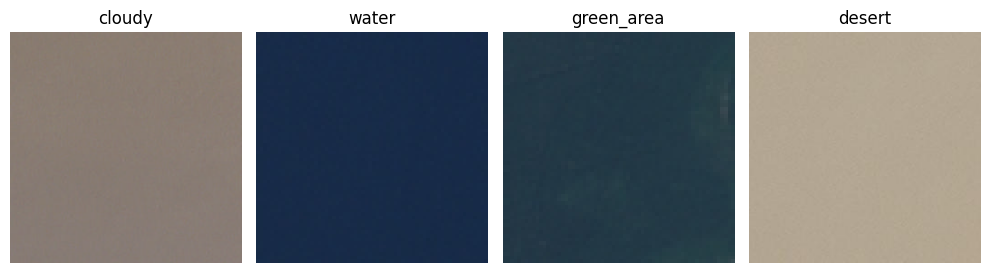

In [56]:
from PIL import Image
plt.figure(figsize=(10, 6))

for i, label in enumerate(df['label'].unique()):
    sample = df[df['label'] == label].sample(1).iloc[0]
    img = Image.open(sample['image_path'])
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [57]:
sizes = []

for path in df['image_path'][:200]:  # sample for speed
    img = Image.open(path)
    sizes.append(img.size)

print(set(sizes))

{(256, 256)}


In [58]:
import numpy as np

img = Image.open(df.iloc[0]['image_path'])
img_array = np.array(img)

print("Shape:", img_array.shape)
print("Min pixel:", img_array.min())
print("Max pixel:", img_array.max())

Shape: (256, 256, 4)
Min pixel: 0
Max pixel: 95


Data Preprocessing

In [59]:
import cv2

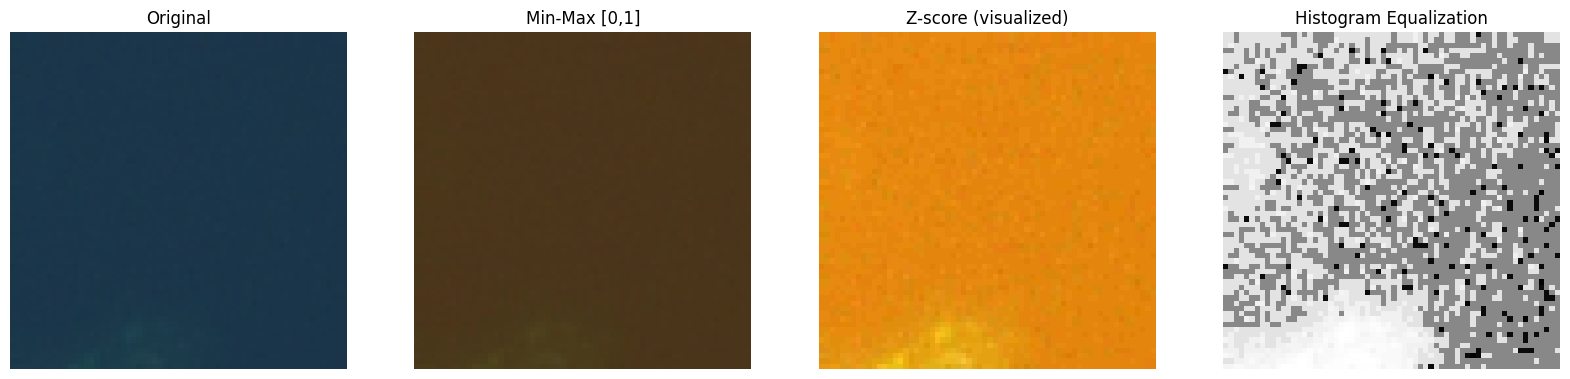

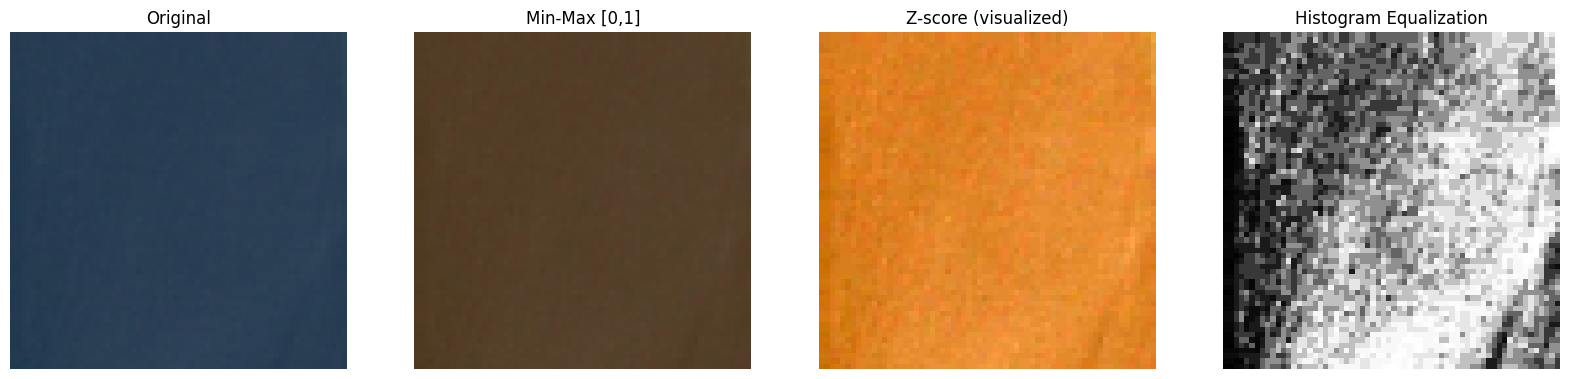

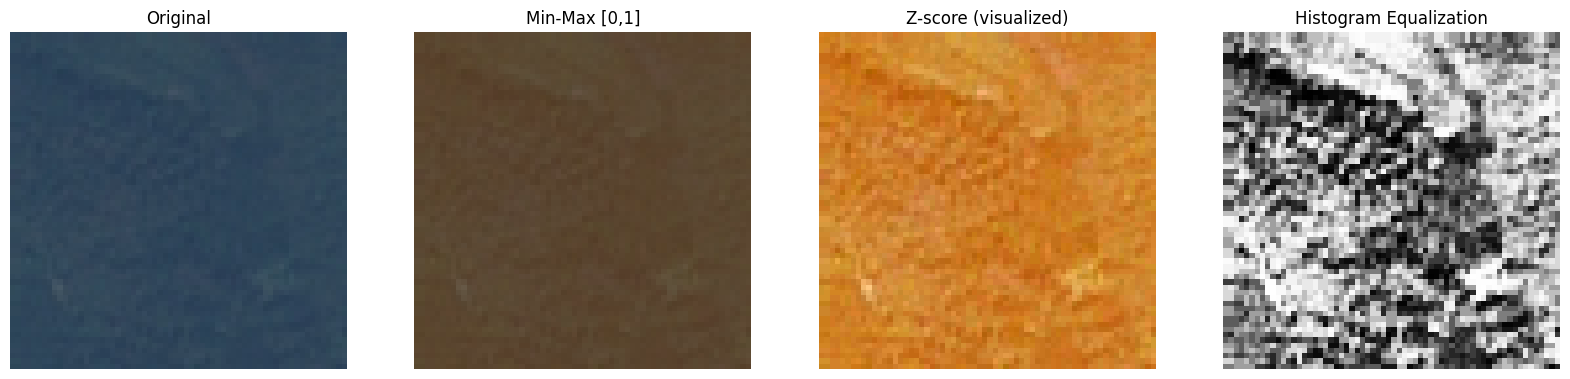

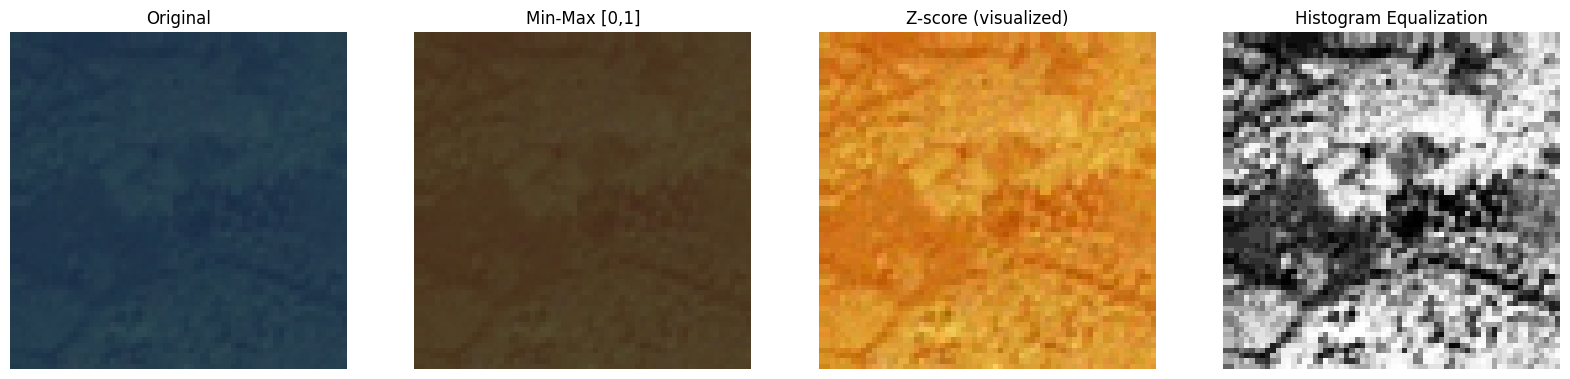

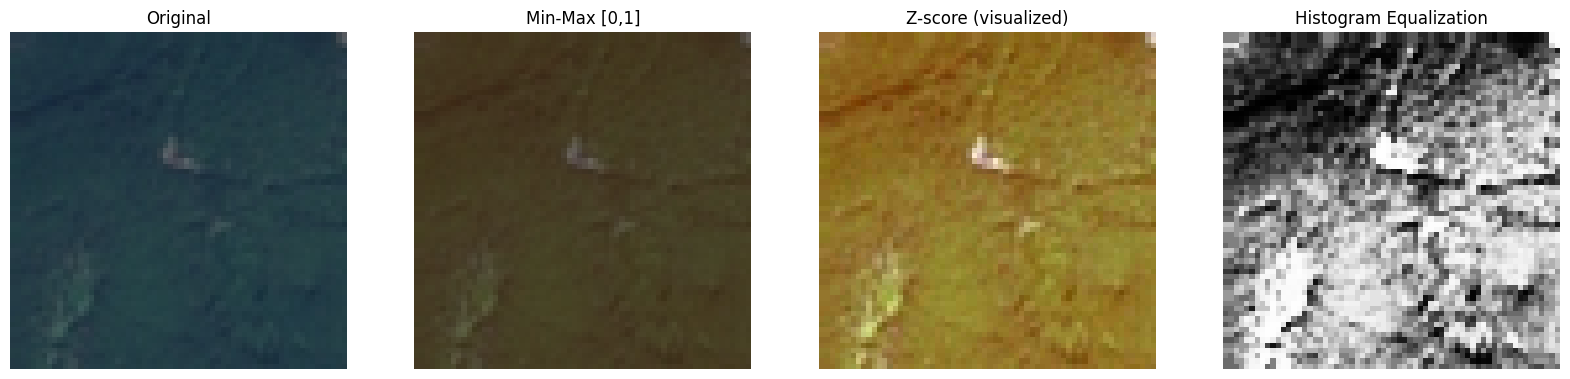

In [ ]:
def normalize_image(image):
    # Min-max 
    min_max = image / 255.0

    # Z-score 
    z_score = (image - np.mean(image)) / (np.std(image) + 1e-8)

    # Histogram 
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist_eq = cv2.equalizeHist(gray)

    return min_max, z_score, hist_eq


sample_paths = set(df['image_path'].sample(5, random_state=42))

for path in df['image_path']:
    image = cv2.imread(path)
    if image is None:
        print(f"Failed: {path}")
        continue

    min_max, z_score, hist_eq = normalize_image(image)

    if path in sample_paths:
        plt.figure(figsize=(20, 5))

        plt.subplot(141)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('Original')
        plt.axis('off')

        plt.subplot(142)
        plt.imshow(min_max)
        plt.title('Min-Max Normalization')
        plt.axis('off')

        plt.subplot(143)
        plt.imshow((z_score - z_score.min()) / (z_score.max() - z_score.min()))
        plt.title('Z-score Normalization')
        plt.axis('off')

        plt.subplot(144)
        plt.imshow(hist_eq, cmap='gray')
        plt.title('Histogram')
        plt.axis('off')

        plt.show()